# Supplementary: Baseline-corrected individual line profiles - P14

This notebook renders the multi-panel figure for the paper’s supplemen, Supp Figure S5:
- Top row: **Epon 1–3** (blue)
- Bottom row: **CPD 1–4** (red)

In [7]:
# ==== P14 supplementary figure (baseline-corrected individual profiles) ====

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Set your 7 CSVs: 3×Epon then 4×CPD
P14_FILE_PATHS = [
    "/data/P14/P14_Epon_lineprofiles_SK101_p1_s9_n25_.csv",
    "/data/P14/P14_Epon_lineprofiles_SK101_p3_s1_n25_.csv",
    "/data/P14/P14_Epon_lineprofiles_SK106_p1_s1_n25_.csv",
    "/data/P14/P14_CPD_lineprofile_SK277_p1_s2_n25.csv",
    "/data/P14/P14_CPD_lineprofiles_SK271_p1_s2_n25.csv",
    "/data/P14/P14_CPD_lineprofile_SK282_p1_s2_n25.csv",
    "/data/P14/P14_CPD_lineprofile_SK287_p1_s2_n25.csv"

]

OUT_SVG = "supp_corrected_profiles_P14.svg"

PIXELS_TO_UM = 0.325       # P14 pixel size (µm)
INVERT_SIGN  = True        # P14 convention
X_LIMS = (0, 10)
Y_LIMS = (-1.1e-2, 1.0e-3) # matches your visual range

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

In [9]:
def safe_read_csv(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")
    return pd.read_csv(file_path, header=None, low_memory=False)

def extract_dist_and_profiles(df, pixels_to_um=0.325, invert=True):
    """Col 0 = pixels → µm; profiles = every other col starting at 1; optional invert."""
    dist_um = df.iloc[:, 0].to_numpy(dtype=float) * pixels_to_um
    profs   = df.iloc[:, 1::2].to_numpy(dtype=float)
    if invert:
        profs = -profs
    return dist_um, profs

def baseline_correct_profiles(dist_um, profiles):
    """Per-profile baseline correction using fixed windows [0.2–1.3] ∪ [8.2–9.9] µm."""
    mask = ((dist_um >= 0.2) & (dist_um <= 1.3)) | ((dist_um >= 8.2) & (dist_um <= 9.9))
    corrected = np.empty_like(profiles)
    for i in range(profiles.shape[1]):
        base_mean = np.mean(profiles[mask, i])
        corrected[:, i] = profiles[:, i] - base_mean
    return corrected

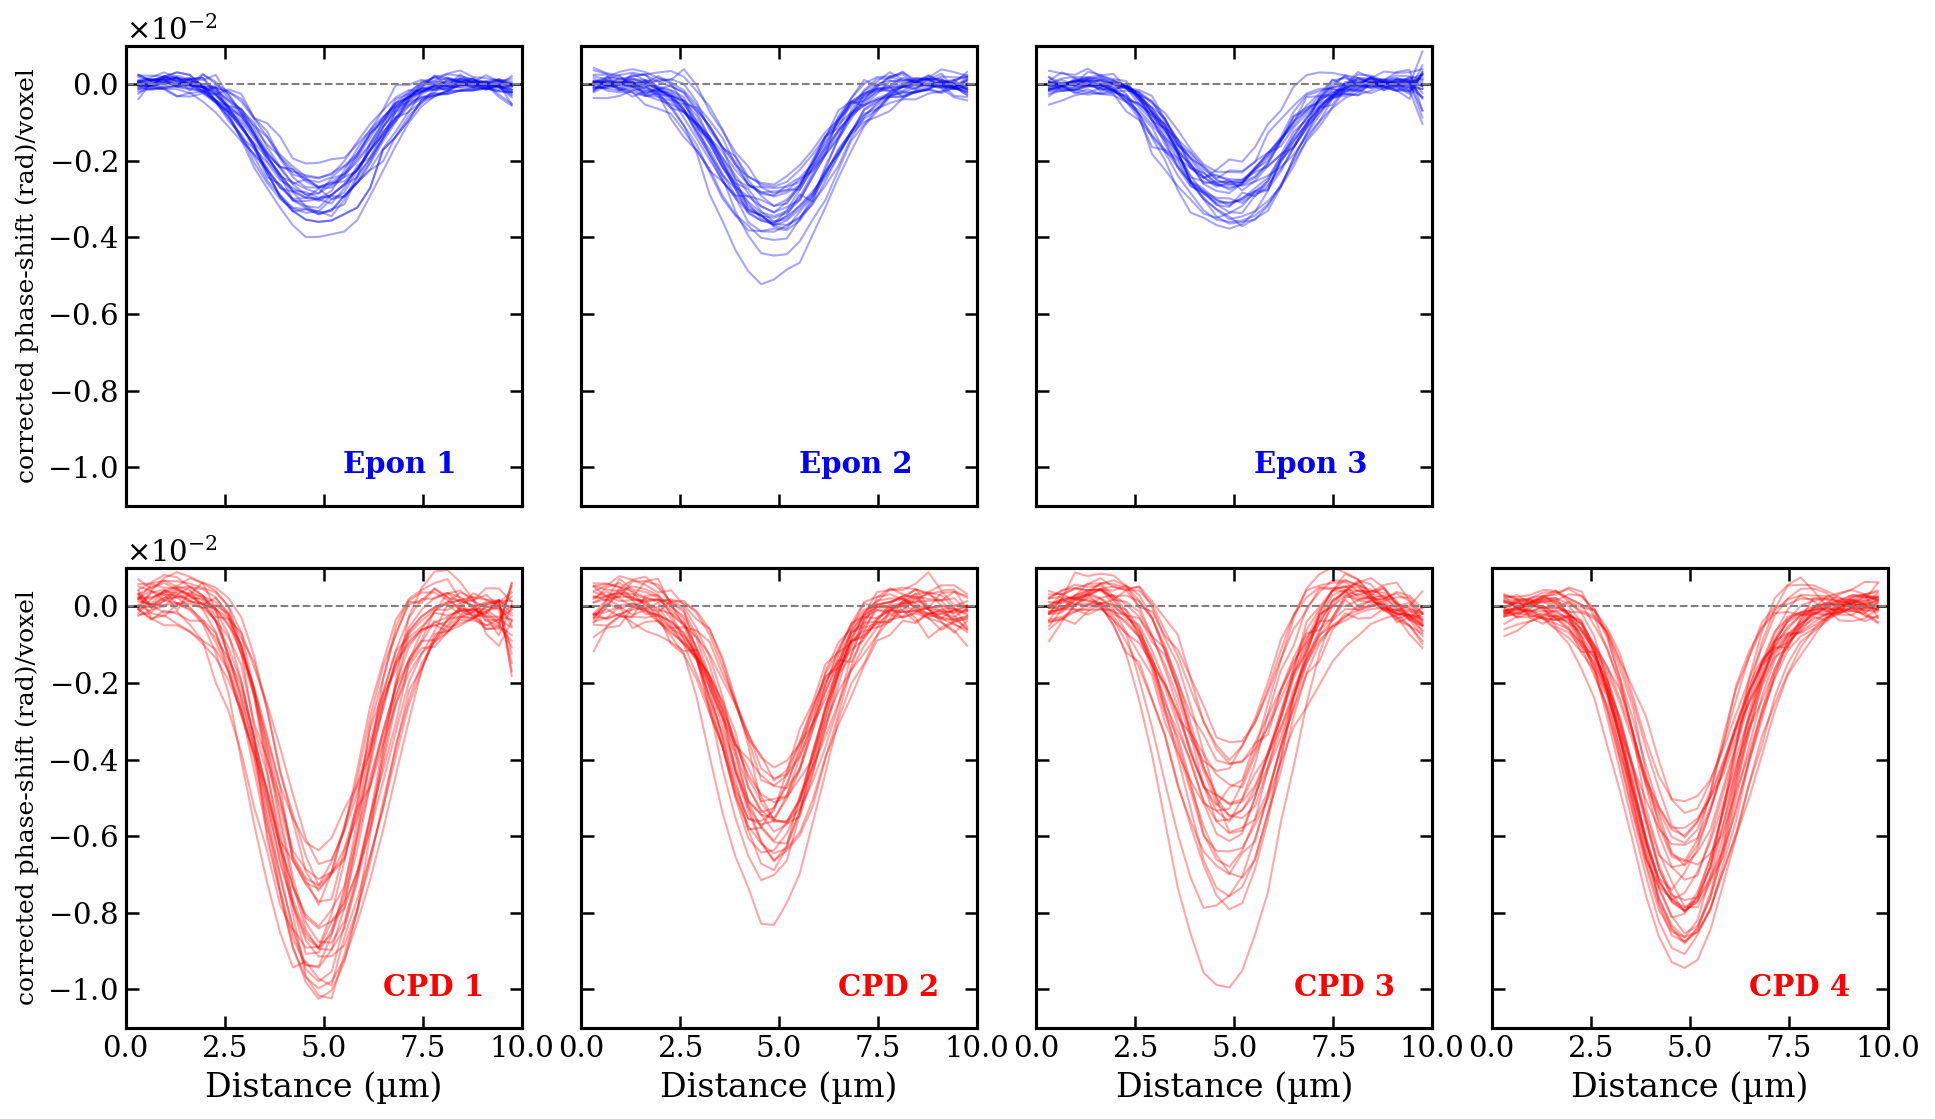

In [11]:
# Load & process
processed = []
for fp in P14_FILE_PATHS:
    df = safe_read_csv(fp)
    dist_um, profs = extract_dist_and_profiles(df, pixels_to_um=PIXELS_TO_UM, invert=INVERT_SIGN)
    corr = baseline_correct_profiles(dist_um, profs)
    processed.append((dist_um, corr))

# Labels per panel
panel_labels = ["Epon 1", "Epon 2", "Epon 3", "CPD 1", "CPD 2", "CPD 3", "CPD 4"]

# Layout: 2 rows × 4 cols; top-right left empty to match your grid style
fig, axes = plt.subplots(2, 4, figsize=(13.5, 8), sharex=True, sharey=True)

# Plot Epon (top row: indices 0..2)
for i in range(3):
    dist_um, corr = processed[i]
    ax = axes[0, i]
    for k in range(corr.shape[1]):
        ax.plot(dist_um, corr[:, k], color="blue", alpha=0.35, linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.text(0.55, 0.07, panel_labels[i], color="blue", fontsize=14, transform=ax.transAxes, fontweight="bold")

# Empty top-right (col 3) to keep 3 Epon panels
axes[0, 3].axis("off")

# Plot CPD (bottom row: indices 3..6)
for j in range(4):
    dist_um, corr = processed[3 + j]
    ax = axes[1, j]
    for k in range(corr.shape[1]):
        ax.plot(dist_um, corr[:, k], color="red", alpha=0.35, linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.text(0.65, 0.07, panel_labels[3 + j], color="red", fontsize=14, transform=ax.transAxes, fontweight="bold")

# Cosmetics
for r in range(2):
    for c in range(4):
        ax = axes[r, c]
        if r == 0 and c == 3:     # the intentionally empty panel
            continue
        ax.set_xlim(*X_LIMS)
        ax.set_ylim(*Y_LIMS)
        ax.tick_params(axis='both', direction='in', length=6, width=1.2, top=True, right=True)
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((0, 0))   # always show ×10^n
        ax.yaxis.set_major_formatter(fmt)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

# Row labels and x-labels
axes[0,0].set_ylabel("corrected phase-shift (rad)/voxel", fontsize=12)
axes[1,0].set_ylabel("corrected phase-shift (rad)/voxel", fontsize=12)
for j in range(4):
    axes[1,j].set_xlabel("Distance (µm)", fontsize=16)

plt.tight_layout(rect=[0.03, 0.02, 0.995, 0.98])
plt.savefig(OUT_SVG, format="svg", dpi=300, bbox_inches="tight")
plt.show()

#print(f"Saved: {OUT_SVG}")